# Avaliação de Modelos

Quais melhores modelos para testar as metricas
- Metricas a serem validadas:
    - F1 Score
    - ROC-AUC
- Modelos a serem testados:
    - Regressão
    - Decision Tree
    - randomforest
    - XGBoost

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,recall_score, precision_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from src.data.load_data import import_dataset
from src.config import features, features_cat, features_num, target
from src.preprocess import churn_mapped, create_preprocessor, train_test, total_charges



In [2]:
df = import_dataset(r"..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = total_charges(df)

In [3]:

X = df[features]
y = churn_mapped(df, target)


X_train, X_test, y_train, y_test = train_test(X,y)


In [4]:
preprocessor = create_preprocessor(features_num, features_cat)

In [5]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000))
])
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

In [7]:
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7374024130589071
Recall:  0.7834224598930482
Precision:  0.5034364261168385
F1-Score:  0.6129707112970711
ROC-AUC:  0.8414063912785139


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



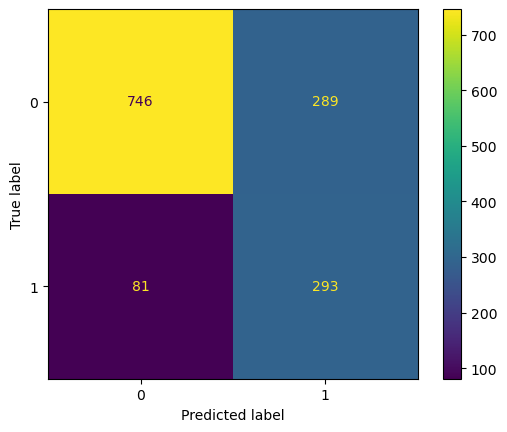

In [9]:
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))

In [10]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [11]:
preprocessor_tree = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
            ],
        remainder='passthrough'
)
pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(max_depth= 5, min_samples_split= 10, min_samples_leaf= 5, class_weight='balanced',random_state=42))
])
pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

In [13]:
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7551454932576295
Recall:  0.7593582887700535
Precision:  0.5269016697588126
F1-Score:  0.6221248630887185
ROC-AUC:  0.8322793148880105


In [14]:
from sklearn.ensemble import RandomForestClassifier 

In [15]:
preprocessor_rf = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
            ],
        remainder='passthrough'
)
pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(max_depth= 5, min_samples_split= 10, min_samples_leaf= 5, class_weight='balanced',random_state=42))
])
pipeline.fit(X_train, y_train)


pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

In [17]:
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7374024130589071
Recall:  0.7887700534759359
Precision:  0.5034129692832765
F1-Score:  0.6145833333333334
ROC-AUC:  0.8390296830194528


In [18]:
from xgboost import XGBClassifier

In [19]:
preprocessor = create_preprocessor(features_num, features_cat)

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric = 'logloss'))
])

In [20]:
pipeline_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
y_pred = pipeline_xgb.predict(X_test)
y_proba = pipeline_xgb.predict_proba(X_test)[:,1]

In [22]:
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ', precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

print(classification_report(y_test, y_pred))

Accuracy:  0.7849538679914834
Recall:  0.5427807486631016
Precision:  0.6059701492537314
F1-Score:  0.5726375176304654
ROC-AUC:  0.8255961145986721
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.61      0.54      0.57       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [23]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

In [24]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(7043, 19)
(5634, 19)
(1409, 19)
